In [1]:
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gzip
import urllib.request as request
import os
import torch.optim as optim
import torchvision.datasets as datasets
import h5py
import time
import pandas as pd
import random
import math

from copy import deepcopy
from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torch.utils.data import Subset
from torchmetrics.image import StructuralSimilarityIndexMeasure
from pytorch_msssim import ssim
from IPython.display import display
from tqdm.auto import tqdm

In [2]:
SEED = 42
FILE_PATH = "Diffusion_jets_procesados_por_canal.hdf5"

CHANNEL_NAMES = ["ECAL", "HCAL", "TRACKER"]

NORMALIZATION_PERCENTILE = 99.5
SPLIT_SEED = 42

USE_SMALL_SUBSET = True
TRAIN_SMALL_SIZE = 10000
VAL_SMALL_SIZE = 2500
TEST_SMALL_SIZE = 2500

BATCH_SIZE = 16
NUM_EPOCHS = 20
LEARNING_RATE = 2e-4

LATENT_CHANNELS = 4
BASE_CHANNELS = 64

BETA_MAX = 1e-3
KL_START_EPOCH = 5
KL_WARMUP_EPOCHS = 15

ACTIVE_THRESHOLD_01 = 1e-4
ACTIVE_WEIGHT = 5.0
BACKGROUND_WEIGHT = 1.0
ENERGY_WEIGHT = 1.0
BACKGROUND_ENERGY_WEIGHT = 0.01
MASK_WEIGHT = 0.02

OCCUPANCY_THRESHOLD = 0.8

In [3]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

## Preprocessing

In [4]:
def raw_to_01(x):
    if x.min() < 0:
        x = (x + 1.0) / 2.0
    return np.clip(x, 0.0, None)

def make_split_indices(total_size, train_fraction=0.80, val_fraction=0.10, seed=42,):
    train_size = int(train_fraction * total_size)
    val_size = int(val_fraction * total_size)
    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(total_size, generator=generator,).numpy()
    train_indices = permutation[:train_size]
    val_indices = permutation[train_size:train_size + val_size]
    test_indices = permutation[train_size + val_size:]

    return train_indices, val_indices, test_indices

def compute_global_active_scale(file_path, train_indices, percentile=99.5, chunk_size=512,):
    
    sorted_indices = np.sort(np.asarray(train_indices, dtype=np.int64))
    active_chunks = []

    with h5py.File(file_path, "r") as file:
        dataset = file["X_diffusion"]

        for start in range(0, len(sorted_indices), chunk_size):
            batch_indices = sorted_indices[start:start + chunk_size]
            x = dataset[batch_indices].astype(np.float32)
            x_01 = raw_to_01(x)
            active = x_01[x_01 > 0.0]
            if active.size:
                active_chunks.append(active)

    if not active_chunks:
        return 1.0
    active_values = np.concatenate(active_chunks)
    return float(np.percentile(active_values, percentile))

In [5]:
class IndexedJetsDataset(Dataset):  
    def __init__(self, file_path,indices, global_scale,):
        super().__init__()

        self.indices = np.asarray(indices, dtype=np.int64)
        self.global_scale = float(global_scale)

        if self.global_scale <= 0:
            raise ValueError("global_scale debe ser positiva.")

        order = np.argsort(self.indices)
        sorted_indices = self.indices[order]

        with h5py.File(file_path, "r") as file:
            x_sorted = file["X_diffusion"][sorted_indices].astype(np.float32)
            y_sorted = file["y"][sorted_indices].astype(np.int64)

        inverse_order = np.argsort(order)
        x = x_sorted[inverse_order]
        self.y = y_sorted[inverse_order]
        x_01 = raw_to_01(x)
        x_01 = np.clip(x_01 / (self.global_scale + 1e-8),0.0,1.0,)
        self.x = (2.0 * x_01 - 1.0).astype(np.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, index):
        image = torch.from_numpy(self.x[index]).permute(2, 0, 1).float()
        label = torch.tensor(self.y[index], dtype=torch.long,)
        return image, label


In [6]:
with h5py.File(FILE_PATH, "r") as file:
    total_size = file["X_diffusion"].shape[0]

train_indices_full, val_indices_full, test_indices_full = (make_split_indices(total_size=total_size,seed=SPLIT_SEED,))

if USE_SMALL_SUBSET:
    train_indices = train_indices_full[:TRAIN_SMALL_SIZE]
    val_indices = val_indices_full[:VAL_SMALL_SIZE]
    test_indices = test_indices_full[:TEST_SMALL_SIZE]
else:
    train_indices = train_indices_full
    val_indices = val_indices_full
    test_indices = test_indices_full

global_train_scale = compute_global_active_scale(file_path=FILE_PATH, train_indices=train_indices, percentile=NORMALIZATION_PERCENTILE,)

train_dataset = IndexedJetsDataset(FILE_PATH, train_indices, global_train_scale,)
val_dataset = IndexedJetsDataset(FILE_PATH, val_indices, global_train_scale,)
test_dataset = IndexedJetsDataset(FILE_PATH, test_indices, global_train_scale,)

train_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=train_generator,)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=0,)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,)

print("Total:", total_size)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print(f"Escala global P{NORMALIZATION_PERCENTILE}: {global_train_scale:.8f}")


Total: 139306
Train: 10000
Validation: 2500
Test: 2500
Escala global P99.5: 0.02826625


In [7]:
images_batch, labels_batch = next(iter(train_loader))

print("Images:", images_batch.shape)
print("Labels:", labels_batch.shape)
print("Min:", images_batch.min().item())
print("Max:", images_batch.max().item())
print("Mean:", images_batch.mean().item())
print("Std:", images_batch.std().item())


Images: torch.Size([16, 3, 64, 64])
Labels: torch.Size([16])
Min: -1.0
Max: 1.0
Mean: -0.996368944644928
Std: 0.048466820269823074


In [8]:
def ejemplo_imagenes(images, labels):

    fig, axs = plt.subplots(ncols=len(images), nrows=1, figsize=(12,3))

    for i in range(len(images)):
        imagen_lista = np.transpose(images[i], (1, 2, 0))
        val_min = imagen_lista.min()
        val_max = imagen_lista.max()
        if val_max > val_min: 
            imagen_lista = (imagen_lista - val_min) / (val_max - val_min)
        label_val = labels[i].item() if hasattr(labels[i], 'item') else labels[i]
        print(f"Imagen {i} - Min real: {val_min:.4f}, Max real: {val_max:.4f}")

        axs[i].imshow(imagen_lista)
        axs[i].set_title(f'Label: {label_val}')
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_xlabel(f'Index: {i}')
    plt.tight_layout()
    plt.show()

Imagen 0 - Min real: -1.0000, Max real: 1.0000
Imagen 1 - Min real: -1.0000, Max real: 1.0000
Imagen 2 - Min real: -1.0000, Max real: 1.0000
Imagen 3 - Min real: -1.0000, Max real: 0.7728
Imagen 4 - Min real: -1.0000, Max real: 1.0000


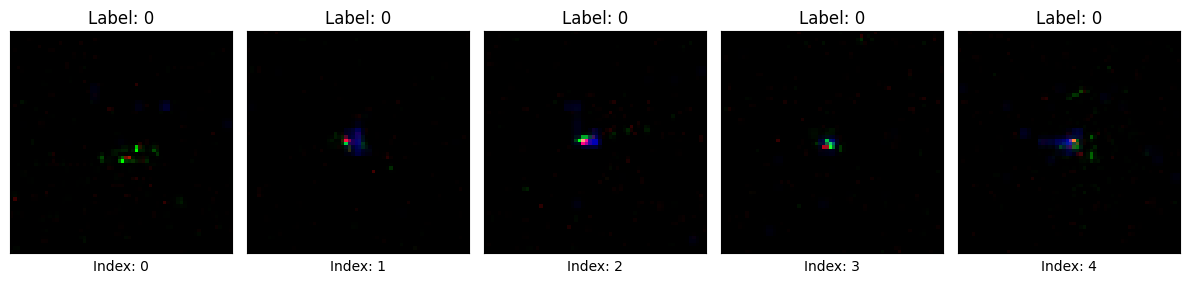

In [9]:
imagenes_ejemplo = np.stack([train_dataset[i][0].numpy() for i in range(5)])
etiquetas_ejemplo = [train_dataset[i][1] for i in range(5)]

ejemplo_imagenes(imagenes_ejemplo, etiquetas_ejemplo)

## VAE

In [10]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.norm1 = nn.GroupNorm(8, in_channels)
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
        )

        self.norm2 = nn.GroupNorm(8, out_channels)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
        )

        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1)
        )

    def forward(self, x):
        h = self.conv1(F.silu(self.norm1(x)))
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

In [ ]:
class JetSpatialVAE(nn.Module):

    def __init__(self, in_channels=3, latent_channels=4, base_channels=64):
        super().__init__()
        self.latent_channels = latent_channels

        # Encoder: 64 a 32 a 16.
        self.enc_in = nn.Conv2d(
            in_channels,
            base_channels,
            kernel_size=3,
            padding=1,
        )
        self.enc_block1 = ResBlock(base_channels, base_channels)

        self.down1 = nn.Conv2d(
            base_channels,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1,
        )
        self.enc_block2 = ResBlock(
            base_channels * 2,
            base_channels * 2,
        )

        self.down2 = nn.Conv2d(
            base_channels * 2,
            base_channels * 4,
            kernel_size=4,
            stride=2,
            padding=1,
        )
        self.enc_block3 = ResBlock(
            base_channels * 4,
            base_channels * 4,
        )

        self.enc_refine16 = nn.Conv2d(
            base_channels * 4,
            base_channels * 4,
            kernel_size=3,
            padding=1,
        )
        self.enc_mid = ResBlock(
            base_channels * 4,
            base_channels * 4,
        )

        self.to_moments = nn.Conv2d(
            base_channels * 4,
            2 * latent_channels,
            kernel_size=3,
            padding=1,
        )

        # Decoder: 16 a 32 a 64.
        self.dec_in = nn.Conv2d(
            latent_channels,
            base_channels * 4,
            kernel_size=3,
            padding=1,
        )
        self.dec_mid = ResBlock(
            base_channels * 4,
            base_channels * 4,
        )

        self.dec_refine16 = nn.Sequential(
            nn.Conv2d(
                base_channels * 4,
                base_channels * 4,
                kernel_size=3,
                padding=1,
            ),
            ResBlock(
                base_channels * 4,
                base_channels * 4,
            ),
        )

        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(
                base_channels * 4,
                base_channels * 2,
                kernel_size=3,
                padding=1,
            ),
        )
        self.dec_block1 = ResBlock(
            base_channels * 2,
            base_channels * 2,
        )

        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(
                base_channels * 2,
                base_channels,
                kernel_size=3,
                padding=1,
            ),
        )
        self.dec_block2 = ResBlock(
            base_channels,
            base_channels,
        )

        self.out_norm = nn.GroupNorm(8, base_channels)

        self.mask_head = nn.Conv2d(
            base_channels,
            in_channels,
            kernel_size=3,
            padding=1,
        )
        self.intensity_head = nn.Conv2d(
            base_channels,
            in_channels,
            kernel_size=3,
            padding=1,
        )

        nn.init.zeros_(self.mask_head.weight)
        nn.init.zeros_(self.intensity_head.weight)

        mask_prior = 0.01
        mask_bias = np.log(mask_prior / (1.0 - mask_prior))
        nn.init.constant_(self.mask_head.bias, float(mask_bias))
        nn.init.constant_(self.intensity_head.bias, -5.0)

    def encode(self, x):
        h = self.enc_block1(self.enc_in(x))
        h = self.enc_block2(self.down1(h))
        h = self.enc_block3(self.down2(h))
        h = self.enc_refine16(h)
        h = self.enc_mid(h)

        mu, log_var = torch.chunk(self.to_moments(h), chunks=2, dim=1)
        log_var = torch.clamp(log_var, min=-10.0, max=8.0)

        return mu, log_var

    @staticmethod
    def reparameterize(mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + torch.randn_like(std) * std

    def decode_components(self, z):
        h = self.dec_mid(self.dec_in(z))
        h = self.dec_refine16(h)
        h = self.dec_block1(self.up1(h))
        h = self.dec_block2(self.up2(h))

        features = F.silu(self.out_norm(h))

        mask_logits = self.mask_head(features)
        intensity_logits = self.intensity_head(features)

        mask_probability = torch.sigmoid(mask_logits)
        intensity_01 = torch.sigmoid(intensity_logits)

        reconstruction_01 = mask_probability * intensity_01
        reconstruction = 2.0 * reconstruction_01 - 1.0

        return reconstruction, mask_logits, mask_probability, intensity_01

    def decode(self, z):
        reconstruction, _, _, _ = self.decode_components(z)
        return reconstruction

    def decode_hard(self, z, probability_threshold=0.8):
        _, _, mask_probability, intensity_01 = self.decode_components(z)
        hard_mask = (mask_probability > probability_threshold).to(intensity_01.dtype)
        reconstruction_01 = hard_mask * intensity_01
        return 2.0 * reconstruction_01 - 1.0

    def forward(self, x, deterministic=False, return_components=False):
        mu, log_var = self.encode(x)
        z = mu if deterministic else self.reparameterize(mu, log_var)
        reconstruction, mask_logits, mask_probability, intensity_01 = self.decode_components(z)

        if return_components:
            return reconstruction, mu, log_var, z, mask_logits, mask_probability, intensity_01

        return reconstruction, mu, log_var, z

In [22]:
model_test = JetSpatialVAE(in_channels=3, latent_channels=LATENT_CHANNELS, base_channels=BASE_CHANNELS).to(device)

with torch.no_grad():
    output = model_test(images_batch[:2].to(device), deterministic=False, return_components=True)

(reconstruction_test, mu_test, log_var_test, z_test, mask_logits_test, mask_probability_test, intensity_test) = output

print("Entrada:", images_batch[:2].shape)
print("Latente:", z_test.shape)
print("Reconstrucción:", reconstruction_test.shape)
print("Máscara:", mask_probability_test.shape)
print("Intensidad:", intensity_test.shape)
print("Parámetros:",
    f"{sum(parameter.numel() for parameter in model_test.parameters()):,}",
)


Entrada: torch.Size([2, 3, 64, 64])
Latente: torch.Size([2, 4, 16, 16])
Reconstrucción: torch.Size([2, 3, 64, 64])
Máscara: torch.Size([2, 3, 64, 64])
Intensidad: torch.Size([2, 3, 64, 64])
Parámetros: 7,702,350


In [ ]:
def masked_mean(values, mask, eps=1e-8):
    return (values * mask).sum() / (mask.sum() + eps)

def jet_vae_loss(reconstruction, target, mu, log_var, mask_logits, beta, active_thr_01=1e-4, active_weight=5.0, background_weight=1.0, energy_weight=1.0, background_energy_weight=0.01, mask_weight=0.02):
    reconstruction_01 = ((reconstruction + 1.0) / 2.0).clamp(0.0, 1.0)
    target_01 = ((target + 1.0) / 2.0).clamp(0.0, 1.0)
    active_mask = (target_01 > active_thr_01).to(target.dtype)
    background_mask = 1.0 - active_mask
    absolute_error = torch.abs(reconstruction_01 - target_01)
    active_l1 = masked_mean(absolute_error,active_mask)
    background_l1 = masked_mean(absolute_error, background_mask,)
    reconstruction_loss = (active_weight * active_l1 + background_weight * background_l1)

    energy_reconstruction = reconstruction_01.sum(dim=(-2, -1))
    energy_target = target_01.sum(dim=(-2, -1))
    energy_loss = F.smooth_l1_loss(torch.log1p(energy_reconstruction), torch.log1p(energy_target), reduction="mean")

    false_background_energy = (reconstruction_01 * background_mask).sum(dim=(-2, -1))
    background_energy_loss = torch.log1p(false_background_energy).mean()

    positive_count = active_mask.sum(dim=(0, 2, 3))
    negative_count = background_mask.sum(dim=(0, 2, 3))

    positive_weight = (negative_count/ positive_count.clamp_min(1.0)).clamp(min=1.0, max=30.0)
    positive_weight = positive_weight.view(1, -1, 1, 1,).detach()

    mask_loss = F.binary_cross_entropy_with_logits(mask_logits, active_mask, pos_weight=positive_weight, reduction="mean")
    kl_loss = 0.5 * (mu.pow(2) + log_var.exp() - 1.0 - log_var).mean()
    total_loss = (reconstruction_loss + energy_weight * energy_loss + background_energy_weight * background_energy_loss + mask_weight * mask_loss + beta * kl_loss)

    components = {
        "loss": total_loss,
        "reconstruction": reconstruction_loss,
        "active_l1": active_l1,
        "background_l1": background_l1,
        "energy": energy_loss,
        "background_energy": background_energy_loss,
        "mask_bce": mask_loss,
        "kl": kl_loss,
    }

    return total_loss, components


In [24]:
def accumulate_metrics(metric_sums, components, batch_size):
    for key, value in components.items():
        metric_sums[key] = (metric_sums.get(key, 0.0) + value.detach().item() * batch_size)

def average_metrics(metric_sums, n_examples):
    return {key: value / max(n_examples, 1) for key, value in metric_sums.items()}

def beta_for_epoch(epoch, beta_max,kl_start_epoch, kl_warmup_epochs):
    if epoch < kl_start_epoch:
        return 0.0
    progress = min(1.0,(epoch - kl_start_epoch + 1) / max(kl_warmup_epochs, 1),)
    return beta_max * progress

@torch.no_grad()
def evaluate_vae_epoch(model, data_loader, beta, device,):
    model.eval()

    totals = {}
    n_examples = 0

    for images, _ in data_loader:
        images = images.to(device)
        (reconstruction, mu, log_var, _, mask_logits, _, _) = model(images, deterministic=True, return_components=True)
        _, components = jet_vae_loss(reconstruction=reconstruction, target=images, mu=mu, log_var=log_var, mask_logits=mask_logits, beta=beta, active_thr_01=ACTIVE_THRESHOLD_01, active_weight=ACTIVE_WEIGHT, background_weight=BACKGROUND_WEIGHT, energy_weight=ENERGY_WEIGHT, background_energy_weight=BACKGROUND_ENERGY_WEIGHT, mask_weight=MASK_WEIGHT)
        batch_size = images.size(0)
        accumulate_metrics(totals, components, batch_size)
        n_examples += batch_size

    return average_metrics(totals, n_examples)


def train_jet_vae(train_loader, val_loader, device, num_epochs=20, learning_rate=2e-4,patience=12):
    model = JetSpatialVAE(in_channels=3, latent_channels=LATENT_CHANNELS,base_channels=BASE_CHANNELS).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4, min_lr=1e-6,)

    history = {
        "train": [],
        "val": [],
        "beta": [],
        "lr": [],
    }

    best_validation_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        beta = beta_for_epoch(epoch=epoch, beta_max=BETA_MAX, kl_start_epoch=KL_START_EPOCH, kl_warmup_epochs=KL_WARMUP_EPOCHS,)
        model.train()
        totals = {}
        n_examples = 0

        for images, _ in train_loader:
            images = images.to(device)
            optimizer.zero_grad(set_to_none=True)

            (reconstruction, mu, log_var, _, mask_logits, _, _,) = model(images, deterministic=False, return_components=True)

            loss, components = jet_vae_loss(reconstruction=reconstruction, target=images, mu=mu, log_var=log_var, mask_logits=mask_logits, beta=beta, active_thr_01=ACTIVE_THRESHOLD_01, active_weight=ACTIVE_WEIGHT, background_weight=BACKGROUND_WEIGHT, energy_weight=ENERGY_WEIGHT, background_energy_weight=BACKGROUND_ENERGY_WEIGHT, mask_weight=MASK_WEIGHT,)

            if not torch.isfinite(loss):
                raise RuntimeError(f"Loss no finita en época {epoch + 1}: {loss.item()}")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_size = images.size(0)
            accumulate_metrics(totals, components, batch_size)
            n_examples += batch_size

        train_metrics = average_metrics(totals, n_examples)

        validation_metrics = evaluate_vae_epoch(model=model, data_loader=val_loader, beta=beta, device=device)
        scheduler.step(validation_metrics["loss"])
        current_lr = optimizer.param_groups[0]["lr"]

        history["train"].append(train_metrics)
        history["val"].append(validation_metrics)
        history["beta"].append(beta)
        history["lr"].append(current_lr)

        print(
            f"Epoch {epoch + 1:03d}/{num_epochs} | "
            f"beta={beta:.2e} | "
            f"lr={current_lr:.2e} | "
            f"train={train_metrics['loss']:.6f} | "
            f"val={validation_metrics['loss']:.6f} | "
            f"active={validation_metrics['active_l1']:.6f} | "
            f"bg={validation_metrics['background_l1']:.6f} | "
            f"energy={validation_metrics['energy']:.6f} | "
            f"bgE={validation_metrics['background_energy']:.6f} | "
            f"mask={validation_metrics['mask_bce']:.6f} | "
            f"KL={validation_metrics['kl']:.6f}"
        )

        if validation_metrics["loss"] < best_validation_loss - 1e-6:
            best_validation_loss = validation_metrics["loss"]
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping en época {epoch + 1}. Mejor val loss: {best_validation_loss:.6f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model.to(device), history

In [25]:
seed_everything(SEED)

vae_model, vae_history = train_jet_vae(train_loader=train_loader, val_loader=val_loader, device=device, num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE, patience=12)

Epoch 001/20 | beta=0.00e+00 | lr=2.00e-04 | train=0.311504 | val=0.231665 | active=0.028905 | bg=0.001289 | energy=0.039550 | bgE=1.739788 | mask=1.445070 | KL=22.020491
Epoch 002/20 | beta=0.00e+00 | lr=2.00e-04 | train=0.212223 | val=0.236948 | active=0.029630 | bg=0.001078 | energy=0.049822 | bgE=1.579626 | mask=1.105135 | KL=29.081175
Epoch 003/20 | beta=0.00e+00 | lr=2.00e-04 | train=0.172977 | val=0.159226 | active=0.023326 | bg=0.000728 | energy=0.012586 | bgE=1.276640 | mask=0.825746 | KL=20.199525
Epoch 004/20 | beta=0.00e+00 | lr=2.00e-04 | train=0.148407 | val=0.142608 | active=0.020894 | bg=0.000604 | energy=0.012618 | bgE=1.141933 | mask=0.674713 | KL=16.072177
Epoch 005/20 | beta=0.00e+00 | lr=2.00e-04 | train=0.131695 | val=0.118813 | active=0.018643 | bg=0.000574 | energy=0.003021 | bgE=1.081453 | mask=0.559299 | KL=12.986958
Epoch 006/20 | beta=6.67e-05 | lr=2.00e-04 | train=0.120064 | val=0.113682 | active=0.017830 | bg=0.000483 | energy=0.003789 | bgE=0.950397 | mas

In [26]:
def wasserstein_xy_per_channel(reconstruction, target, eps=1e-8,):
    projection_x_reconstruction = reconstruction.sum(dim=2)
    projection_x_target = target.sum(dim=2)
    projection_y_reconstruction = reconstruction.sum(dim=3)
    projection_y_target = target.sum(dim=3)

    px_reconstruction = projection_x_reconstruction / (projection_x_reconstruction.sum(dim=-1, keepdim=True) + eps)
    px_target = projection_x_target / (projection_x_target.sum(dim=-1, keepdim=True)+ eps)
    py_reconstruction = projection_y_reconstruction / (projection_y_reconstruction.sum(dim=-1, keepdim=True) + eps)
    py_target = projection_y_target / (projection_y_target.sum(dim=-1, keepdim=True)+ eps)

    w1_x = torch.abs(torch.cumsum(px_reconstruction, dim=-1) - torch.cumsum(px_target, dim=-1)).sum(dim=-1)
    w1_y = torch.abs(torch.cumsum(py_reconstruction, dim=-1) - torch.cumsum(py_target, dim=-1)).sum(dim=-1)

    return (w1_x + w1_y).mean()

@torch.no_grad()
def evaluate_reconstructions(model, data_loader, device, probability_threshold=None,):
    model.eval()

    totals = {
        "mae_01": 0.0,
        "mse_01": 0.0,
        "active_mae_01": 0.0,
        "background_mae_01": 0.0,
        "energy_relative_error": 0.0,
        "w1_xy": 0.0,
        "ssim": 0.0,
        "active_frac_real": 0.0,
        "active_frac_recon": 0.0,
    }

    n_examples = 0

    for images, _ in data_loader:
        images = images.to(device)
        (reconstruction, _, _, _, _, mask_probability, intensity_01) = model(images, deterministic=True, return_components=True,)
        images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)

        if probability_threshold is None:
            reconstruction_01 = ((reconstruction + 1.0) / 2.0).clamp(0.0, 1.0)
        else:
            hard_mask = (mask_probability > probability_threshold).to(images.dtype)
            reconstruction_01 = hard_mask * intensity_01

        active_mask = (images_01 > ACTIVE_THRESHOLD_01).to(images.dtype)
        background_mask = 1.0 - active_mask
        absolute_error = torch.abs(reconstruction_01 - images_01)
        true_energy = images_01.sum(dim=(1, 2, 3))
        reconstructed_energy = reconstruction_01.sum(dim=(1, 2, 3))

        batch_metrics = {
            "mae_01": absolute_error.mean(),
            "mse_01": F.mse_loss(reconstruction_01, images_01,),
            "active_mae_01": masked_mean(absolute_error, active_mask),
            "background_mae_01": masked_mean(absolute_error, background_mask),
            "energy_relative_error": (torch.abs(reconstructed_energy - true_energy) / true_energy.clamp_min(1e-8)).mean(),
            "w1_xy": wasserstein_xy_per_channel(reconstruction_01, images_01),
            "ssim": ssim(reconstruction_01, images_01, data_range=1.0, size_average=True),
            "active_frac_real": active_mask.mean(),
            "active_frac_recon": (reconstruction_01 > ACTIVE_THRESHOLD_01).float().mean(),
        }

        batch_size = images.size(0)

        for key, value in batch_metrics.items():
            totals[key] += value.item() * batch_size
        n_examples += batch_size

    return {key: value / n_examples for key, value in totals.items()}


In [27]:
soft_metrics = evaluate_reconstructions(model=vae_model, data_loader=test_loader, device=device, probability_threshold=None)
hard_metrics = evaluate_reconstructions(model=vae_model, data_loader=test_loader, device=device, probability_threshold=OCCUPANCY_THRESHOLD)

print("RECONSTRUCCIÓN SUAVE")
for key, value in soft_metrics.items():
    print(f"{key:28s}: {value:.8f}")

print("\nRECONSTRUCCIÓN HARD p > 0.8")
for key, value in hard_metrics.items():
    print(f"{key:28s}: {value:.8f}")


RECONSTRUCCIÓN SUAVE
mae_01                      : 0.00075579
mse_01                      : 0.00005212
active_mae_01               : 0.01132216
background_mae_01           : 0.00024149
energy_relative_error       : 0.02931403
w1_xy                       : 1.16813972
ssim                        : 0.98924941
active_frac_real            : 0.04638578
active_frac_recon           : 0.15007172

RECONSTRUCCIÓN HARD p > 0.8
mae_01                      : 0.00071482
mse_01                      : 0.00005232
active_mae_01               : 0.01145348
background_mae_01           : 0.00019213
energy_relative_error       : 0.01955524
w1_xy                       : 0.98362908
ssim                        : 0.98923125
active_frac_real            : 0.04638578
active_frac_recon           : 0.06635863


In [28]:
@torch.no_grad()
def show_reconstructions(model, data_loader, device, num_images=6, probability_threshold=0.8, contrast=False, channel_order=(2, 0, 1),):
    model.eval()
    images, _ = next(iter(data_loader))
    images = images[:num_images].to(device)

    (_, _, _, _, _, mask_probability, intensity_01) = model(images, deterministic=True, return_components=True)

    images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
    hard_mask = (mask_probability > probability_threshold).to(images.dtype)
    reconstruction_01 = hard_mask * intensity_01
    images_01 = images_01.cpu()
    reconstruction_01 = reconstruction_01.cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(2.8 * num_images, 5.5),)

    for index in range(num_images):
        original = images_01[index][list(channel_order)]
        reconstruction = reconstruction_01[index][list(channel_order)]

        if contrast:
            active_values = original[original > 1e-6]
            vmax = (torch.quantile(active_values, 0.99).item() if active_values.numel() else 1.0)
            vmax = max(vmax, 1e-8)
            original_display = (original / vmax).clamp(0.0, 1.0)
            reconstruction_display = (reconstruction / vmax).clamp(0.0, 1.0)
        else:
            original_display = original
            reconstruction_display = reconstruction

        axes[0, index].imshow(original_display.permute(1, 2, 0).numpy(), origin="lower")
        axes[0, index].set_title(f"Original\nE={original.sum().item():.2f}")
        axes[0, index].axis("off")
        axes[1, index].imshow(reconstruction_display.permute(1, 2, 0).numpy(), origin="lower",)
        axes[1, index].set_title(f"Reconstrucción\nE={reconstruction.sum().item():.2f}")
        axes[1, index].axis("off")

    plt.tight_layout()
    plt.show()

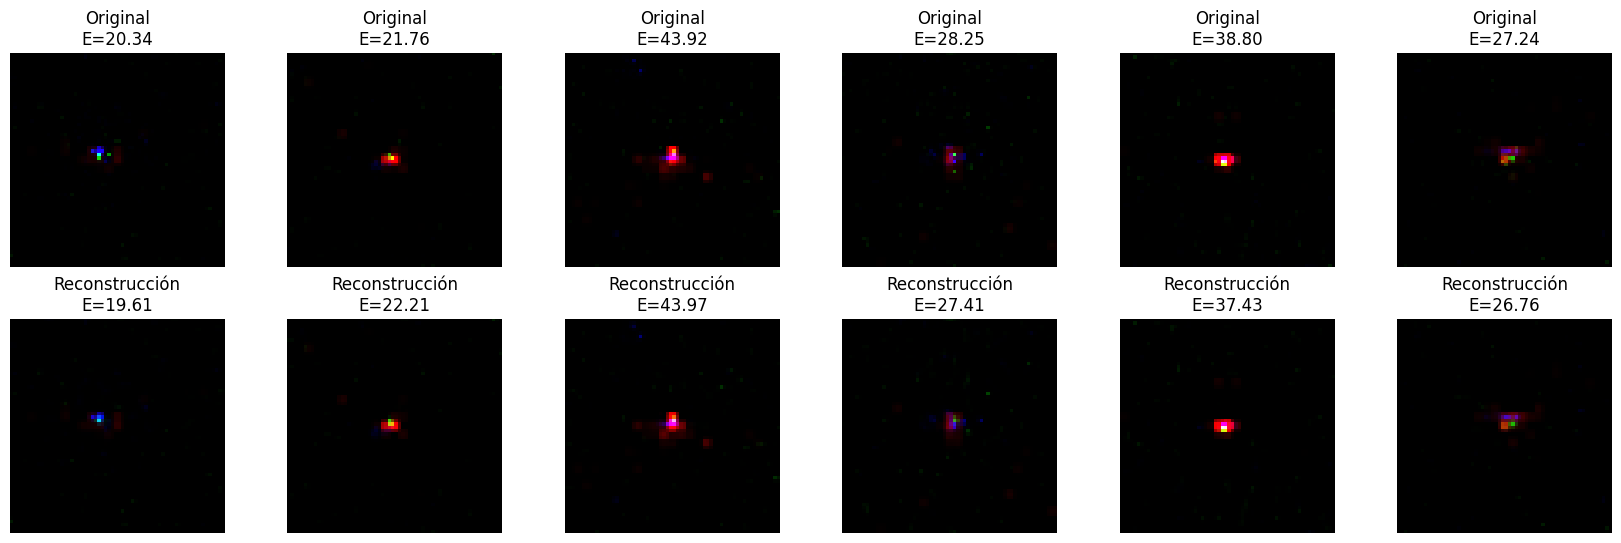

In [29]:
show_reconstructions(
    model=vae_model,
    data_loader=test_loader,
    device=device,
    probability_threshold=OCCUPANCY_THRESHOLD,
    contrast=False,
)

## Metrics

In [30]:
def empirical_w1(values_a, values_b):
    values_a = np.sort(np.asarray(values_a))
    values_b = np.sort(np.asarray(values_b))

    return np.mean(np.abs(values_a - values_b))

@torch.no_grad()
def collect_physics_diagnostics(model, data_loader, device, probability_threshold=0.8, num_radial_bins=32,):
    model.eval()

    energy_real_batches = []
    energy_recon_batches = []
    active_real_batches = []
    active_recon_batches = []
    max_real_batches = []
    max_recon_batches = []

    radial_real_sum = None
    radial_recon_sum = None
    radial_bin_index = None
    radial_centers = None

    for images, _ in data_loader:
        images = images.to(device)

        (_, _, _, _, _, mask_probability, intensity_01) = model(images, deterministic=True, return_components=True)
        images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        hard_mask = (mask_probability > probability_threshold).to(images.dtype)
        reconstruction_01 = hard_mask * intensity_01
        images_01 = images_01.cpu()
        reconstruction_01 = reconstruction_01.cpu()
        batch_size, channels, height, width = images_01.shape

        energy_real_batches.append(images_01.sum(dim=(-2, -1)).numpy())
        energy_recon_batches.append(reconstruction_01.sum(dim=(-2, -1)).numpy())
        active_real_batches.append((images_01 > ACTIVE_THRESHOLD_01).float().mean(dim=(-2, -1)).numpy())
        active_recon_batches.append((reconstruction_01 > ACTIVE_THRESHOLD_01).float().mean(dim=(-2, -1)).numpy())

        max_real_batches.append(images_01.amax(dim=(-2, -1)).numpy())
        max_recon_batches.append(reconstruction_01.amax(dim=(-2, -1)).numpy())

        if radial_bin_index is None:
            y, x = torch.meshgrid(torch.arange(height, dtype=torch.float32),torch.arange(width, dtype=torch.float32), indexing="ij")
            center_y = (height - 1) / 2.0
            center_x = (width - 1) / 2.0
            radius = torch.sqrt((y - center_y) ** 2 + (x - center_x) ** 2)
            radial_edges = torch.linspace(0.0, radius.max().item() + 1e-6, num_radial_bins + 1,)
            radial_centers = (0.5 * (radial_edges[:-1] + radial_edges[1:])).numpy()
            radial_bin_index = (torch.bucketize(radius.reshape(-1), radial_edges, right=False,)- 1).clamp(0, num_radial_bins - 1)
            radial_real_sum = torch.zeros(channels, num_radial_bins,dtype=torch.float64,)
            radial_recon_sum = torch.zeros(channels, num_radial_bins, dtype=torch.float64,)
        real_flat = images_01.reshape(batch_size, channels, -1,).double()
        recon_flat = reconstruction_01.reshape(batch_size, channels, -1,).double()

        for radial_bin in range(num_radial_bins):
            mask = radial_bin_index == radial_bin
            radial_real_sum[:, radial_bin] += (real_flat[:, :, mask].sum(dim=(0, 2)))
            radial_recon_sum[:, radial_bin] += (recon_flat[:, :, mask].sum(dim=(0, 2)))
    radial_real = (radial_real_sum/ radial_real_sum.sum(dim=1, keepdim=True).clamp_min(1e-12)).numpy()
    radial_recon = (radial_recon_sum/ radial_recon_sum.sum(dim=1, keepdim=True).clamp_min(1e-12)).numpy()

    return {
        "energy_real": np.concatenate(energy_real_batches),
        "energy_recon": np.concatenate(energy_recon_batches),
        "active_frac_real": np.concatenate(active_real_batches),
        "active_frac_recon": np.concatenate(active_recon_batches),
        "max_real": np.concatenate(max_real_batches),
        "max_recon": np.concatenate(max_recon_batches),
        "radial_centers": radial_centers,
        "radial_real": radial_real,
        "radial_recon": radial_recon,
    }

def summarize_physics_diagnostics(diagnostics):
    rows = []

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        energy_real = diagnostics["energy_real"][:, channel]
        energy_recon = diagnostics["energy_recon"][:, channel]
        active_real = diagnostics["active_frac_real"][:, channel]
        active_recon = diagnostics["active_frac_recon"][:, channel]
        max_real = diagnostics["max_real"][:, channel]
        max_recon = diagnostics["max_recon"][:, channel]
        radial_real = diagnostics["radial_real"][channel]
        radial_recon = diagnostics["radial_recon"][channel]

        valid_energy = energy_real > 1e-6
        energy_relative_error = np.mean(np.abs(energy_recon[valid_energy] - energy_real[valid_energy])/ energy_real[valid_energy])

        energy_mean_real = energy_real.mean()
        energy_mean_recon = energy_recon.mean()

        rows.append(
            {
                "Canal": channel_name,
                "E real media": energy_mean_real,
                "E recon media": energy_mean_recon,
                "Bias E (%)": 100.0 * (energy_mean_recon - energy_mean_real) / max(energy_mean_real, 1e-8),
                "Error relativo E (%)": 100.0 * energy_relative_error,
                "W1 energía": empirical_w1(energy_real, energy_recon),
                "Fracción activa real": active_real.mean(),
                "Fracción activa recon": active_recon.mean(),
                "Diferencia activa (p.p.)": 100.0 * (active_recon.mean() - active_real.mean()),
                "Máximo real medio": max_real.mean(),
                "Máximo recon medio": max_recon.mean(),
                "W1 máximo": empirical_w1(max_real, max_recon),
                "Radial L1":np.abs(radial_recon - radial_real).sum(),
                "Radial L2": np.sqrt(np.mean((radial_recon - radial_real) ** 2)),
            }
        )

    return pd.DataFrame(rows)

In [31]:
diagnostics = collect_physics_diagnostics(model=vae_model, data_loader=test_loader, device=device, probability_threshold=OCCUPANCY_THRESHOLD, num_radial_bins=32,)
physics_summary = summarize_physics_diagnostics(diagnostics)

display(physics_summary.round(6))

,Canal,E real media,E recon media,Bias E (%),Error relativo E (%),W1 energía,Fracción activa real,Fracción activa recon,Diferencia activa (p.p.),Máximo real medio,Máximo recon medio,W1 máximo,Radial L1,Radial L2
0,ECAL,5.859265,5.888934,0.506373,5.176856,0.044272,0.041333,0.071125,2.979229,0.760318,0.635457,0.124865,0.064856,0.002766
1,HCAL,7.773422,7.928084,1.989634,4.437989,0.163970,0.053148,0.082848,2.970049,0.826301,0.804554,0.033347,0.014217,0.000648
2,TRACKER,11.419732,11.237777,-1.593342,2.581440,0.185585,0.044677,0.045103,0.042578,0.523041,0.517908,0.007514,0.018721,0.000991


## Latent Space

In [32]:
LDM_BATCH_SIZE = 64
LDM_ENCODING_BATCH_SIZE = 64

vae_model.eval()

for parameter in vae_model.parameters():
    parameter.requires_grad_(False)

print("VAE congelado")

VAE congelado


In [73]:
@torch.no_grad()
def encode_dataset_to_mu(model, dataset, device, batch_size=64):   
    model.eval()

    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    mu_batches, label_batches = [], []

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        mu, _ = model.encode(images)
        mu_batches.append(mu.detach().cpu())
        label_batches.append(labels.detach().cpu())

    mu_all = torch.cat(mu_batches, dim=0)
    labels_all = torch.cat(label_batches, dim=0)
    
    return mu_all, labels_all

In [ ]:
ldm_train_mu, ldm_train_labels = encode_dataset_to_mu(model=vae_model, dataset=train_dataset, device=device, batch_size=LDM_ENCODING_BATCH_SIZE)
ldm_val_mu, ldm_val_labels = encode_dataset_to_mu(model=vae_model, dataset=val_dataset, device=device, batch_size=LDM_ENCODING_BATCH_SIZE)
ldm_test_mu, ldm_test_labels = encode_dataset_to_mu(model=vae_model, dataset=test_dataset, device=device, batch_size=LDM_ENCODING_BATCH_SIZE,)

print("Train:", ldm_train_mu.shape)
print("Validation:", ldm_val_mu.shape)
print("Test:", ldm_test_mu.shape)

In [35]:
latent_mean_train = ldm_train_mu.mean(dim=(0, 2, 3), keepdim=True,)
latent_std_train = ldm_train_mu.std(dim=(0, 2, 3), keepdim=True, unbiased=False,).clamp_min(1e-6)

print(f"Media latente de entrenamiento:", latent_mean_train.flatten().numpy())
print(f"Std latente de entrenamiento:", latent_std_train.flatten().numpy(),)

Media latente de entrenamiento: [ 0.05349377 -0.10814887 -0.01567567  0.04054134]
Std latente de entrenamiento: [1.1951165 1.25811   1.124951  1.1686614]


In [36]:
def standardize_latents(latent_tensor, latent_mean, latent_std,):
    return (latent_tensor - latent_mean ) / latent_std.clamp_min(1e-6)

In [37]:
ldm_train_latents = standardize_latents(ldm_train_mu, latent_mean_train, latent_std_train)
ldm_val_latents = standardize_latents(ldm_val_mu, latent_mean_train, latent_std_train)
ldm_test_latents = standardize_latents(ldm_test_mu, latent_mean_train, latent_std_train)

In [38]:
del ldm_train_mu
del ldm_val_mu
del ldm_test_mu

In [39]:
def summarize_latent_tensor(latent_tensor, name):
    channel_mean = latent_tensor.mean(dim=(0, 2, 3))
    channel_std = latent_tensor.std(dim=(0, 2, 3), unbiased=False)
    absolute_latents = latent_tensor.abs()

    print(f"\n{name}")
    print("Shape:", tuple(latent_tensor.shape))
    print(f"Media por canal:", channel_mean.numpy())
    print(f"Std por canal:", channel_std.numpy(),)
    print(f"Media global:", latent_tensor.mean().item())
    print(f"Std global:", latent_tensor.std(unbiased=False).item())
    print(f"Mínimo:", latent_tensor.min().item())
    print(f"Máximo:",latent_tensor.max().item())
    print(f"Fracción |z| > 4:",(absolute_latents > 4.0).float().mean().item())
    print("Fracción |z| > 6:",(absolute_latents > 6.0).float().mean().item())

In [40]:
summarize_latent_tensor(ldm_train_latents, "LATENTES DE ENTRENAMIENTO")
summarize_latent_tensor(ldm_val_latents, "LATENTES DE VALIDACIÓN")
summarize_latent_tensor(ldm_test_latents, "LATENTES DE TEST")


LATENTES DE ENTRENAMIENTO
Shape: (10000, 4, 16, 16)
Media por canal: [ 4.54664217e-08  1.04609875e-07 -6.98417413e-09  7.15255771e-11]
Std por canal: [1.         1.         1.         0.99999994]
Media global: 3.502368883800955e-08
Std global: 1.0
Mínimo: -18.02461814880371
Máximo: 20.087242126464844
Fracción |z| > 4: 0.006646289024502039
Fracción |z| > 6: 0.001685839844867587

LATENTES DE VALIDACIÓN
Shape: (2500, 4, 16, 16)
Media por canal: [-0.00255033  0.00215222  0.00013059 -0.00153946]
Std por canal: [1.0052946 1.0049297 1.0051463 0.9996123]
Media global: -0.0004517411289270967
Std global: 1.0037500858306885
Mínimo: -19.530242919921875
Máximo: 17.445322036743164
Fracción |z| > 4: 0.006648437585681677
Fracción |z| > 6: 0.0016667968593537807

LATENTES DE TEST
Shape: (2500, 4, 16, 16)
Media por canal: [-3.0445623e-05  6.9812225e-04  3.6600305e-04  2.1528970e-03]
Std por canal: [1.0025572 1.0016805 0.9980355 0.9975337]
Media global: 0.000796643435023725
Std global: 0.9999544620513916

In [41]:
ldm_train_dataset = TensorDataset(ldm_train_latents, ldm_train_labels)
ldm_val_dataset = TensorDataset(ldm_val_latents, ldm_val_labels)
ldm_test_dataset = TensorDataset(ldm_test_latents, ldm_test_labels)

In [42]:
ldm_train_generator = (torch.Generator().manual_seed(SEED))
ldm_train_loader = DataLoader(ldm_train_dataset, batch_size=LDM_BATCH_SIZE, shuffle=True, num_workers=0, generator=ldm_train_generator,)
ldm_val_loader = DataLoader(ldm_val_dataset, batch_size=LDM_BATCH_SIZE, shuffle=False, num_workers=0,)
ldm_test_loader = DataLoader(ldm_test_dataset, batch_size=LDM_BATCH_SIZE, shuffle=False, num_workers=0,)

In [43]:
latent_batch, label_batch = next(iter(ldm_train_loader))
print("Latentes:", latent_batch.shape)
print("Etiquetas:", label_batch.shape)
print(f"Media del batch:", latent_batch.mean().item())
print("Std del batch:", latent_batch.std( unbiased=False).item())
print(f"Valores finitos:", torch.isfinite(latent_batch).all().item())

Latentes: torch.Size([64, 4, 16, 16])
Etiquetas: torch.Size([64])
Media del batch: -0.0033890630584210157
Std del batch: 0.9957278370857239
Valores finitos: True


## UNET

In [44]:
class LinearNoiseScheduler:
    def __init__(self, num_timesteps, beta_s, beta_e, device):
        self.num_timesteps = num_timesteps
        self.beta_s = beta_s
        self.beta_e = beta_e
        self.device = device

        self.betas = torch.linspace(beta_s, beta_e, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1.0 - self.alpha_cum_prod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        alpha_cum_prod_prev = torch.cat([torch.tensor([1.0], device=device), self.alpha_cum_prod[:-1]], dim=0)
        self.posterior_variance = (self.betas * (1.0 - alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod))
        self.posterior_mean_coef1 = (self.betas * torch.sqrt(alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod))
        self.posterior_mean_coef2 = (torch.sqrt(self.alphas) * (1.0 - alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod))

    
    def sample_timesteps(self, batch_size):
        return torch.randint(0, self.num_timesteps, (batch_size,), device=self.device)

    def _extract(self, arr, t, x_shape):
        out = arr.gather(0, t)
        return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

    def add_noise(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_alpha_cum_prod_t = self._extract(self.sqrt_alpha_cum_prod, t, x0.shape)
        sqrt_one_minus_alpha_cum_prod_t = self._extract(self.sqrt_one_minus_alpha_cum_prod, t, x0.shape)
        xt = sqrt_alpha_cum_prod_t * x0 + sqrt_one_minus_alpha_cum_prod_t * noise

        return xt, noise
    
    #Comentamos: No es necesario, lo hago por claridad personal.
    """
    @torch.no_grad()
    def sample_prev_timestep(self, xt, noise_pred, t):
        
        if isinstance(t, torch.Tensor):
            t_int = int(t.item())
        else:
            t_int = int(t)

        beta_t = self.betas[t_int]
        alpha_t = self.alphas[t_int]
        alpha_bar_t = self.alpha_cum_prod[t_int]

        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_cum_prod[t_int]
        sqrt_alpha_bar_t = self.sqrt_alpha_cum_prod[t_int]

        x0_pred = (xt - sqrt_one_minus_alpha_bar_t * noise_pred) / sqrt_alpha_bar_t
        x0_pred = torch.clamp(x0_pred, -1.0, 1.0)

        mean = (xt - (beta_t / sqrt_one_minus_alpha_bar_t) * noise_pred)/torch.sqrt(alpha_t)

        if t_int == 0:
            return mean, x0_pred

        variance_t = self.posterior_variance[t_int]
        noise = torch.randn_like(xt)

        x_prev = mean + torch.sqrt(variance_t) * noise

        return x_prev, x0_pred
    
    """   
    @torch.no_grad()
    def sample_prev_timestep_v(self, xt, v_pred, t, clip_x0=True):
        
        if isinstance(t, torch.Tensor):
            t_int = int(t.item())
        else:
            t_int = int(t)

        sqrt_alpha_bar_t = self.sqrt_alpha_cum_prod[t_int]
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_cum_prod[t_int]
        x0_pred = sqrt_alpha_bar_t * xt - sqrt_one_minus_alpha_bar_t * v_pred

        if clip_x0:
            x0_pred = torch.clamp(x0_pred, -1.0, 1.0)

        if t_int == 0:
            return x0_pred, x0_pred

        posterior_mean = (self.posterior_mean_coef1[t_int] * x0_pred + self.posterior_mean_coef2[t_int] * xt)
        posterior_var = self.posterior_variance[t_int]
        noise = torch.randn_like(xt)
        x_prev = posterior_mean + torch.sqrt(posterior_var) * noise

        return x_prev, x0_pred
      

In [45]:
def get_num_groups(channels, max_groups=8):
    for g in reversed(range(1, max_groups + 1)):
        if channels % g == 0:
            return g
    return 1

def sinusoidal_time_embedding(timesteps, dim):
    if timesteps.dim() == 0:
        timesteps = timesteps[None]
    timesteps = timesteps.float()
    half_dim = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half_dim, device=timesteps.device).float() / max(half_dim - 1, 1))
    args = timesteps[:, None] * freqs[None, :]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb

class TimeEmbedding(nn.Module):
    def __init__(self, t_emb_dim):
        super().__init__()
        self.t_emb_dim = t_emb_dim
        self.mlp = nn.Sequential(
            nn.Linear(t_emb_dim, 4 * t_emb_dim),
            nn.SiLU(),
            nn.Linear(4 * t_emb_dim, t_emb_dim)
        )

    def forward(self, t):
        t_emb = sinusoidal_time_embedding(t, self.t_emb_dim)
        return self.mlp(t_emb)

In [46]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_emb_dim, dropout=0.0):
        super().__init__()

        self.norm1 = nn.GroupNorm(get_num_groups(in_channels), in_channels)
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_emb_dim, 2 * out_channels)
        )

        self.norm2 = nn.GroupNorm(get_num_groups(out_channels), out_channels)
        self.dropout = nn.Dropout(dropout)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, t_emb):
        residual = self.skip(x)
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)
        scale_shift = self.time_proj(t_emb)
        scale, shift = scale_shift[:, :, None, None].chunk(2, dim=1)
        h = self.norm2(h)
        h = h * (1.0 + scale) + shift
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return h + residual

In [47]:
class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()

        assert channels % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = channels // num_heads
        self.scale = self.head_dim ** -0.5

        self.norm = nn.GroupNorm(get_num_groups(channels), channels)
        self.qkv = nn.Conv2d(channels, 3 * channels, kernel_size=1)
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        residual = x

        b, c, h, w = x.shape
        x = self.norm(x)

        q, k, v = self.qkv(x).chunk(3, dim=1)

        q = q.reshape(b, self.num_heads, self.head_dim, h * w)
        k = k.reshape(b, self.num_heads, self.head_dim, h * w)
        v = v.reshape(b, self.num_heads, self.head_dim, h * w)

        attn = torch.einsum("bhcn,bhcm->bhnm", q, k) * self.scale
        attn = attn.softmax(dim=-1)

        out = torch.einsum("bhnm,bhcm->bhcn", attn, v)
        out = out.reshape(b, c, h, w)

        return residual + self.proj(out)

In [48]:
class DownBlockStrong(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        t_emb_dim,
        use_attention=False,
        dropout=0.0
    ):
        super().__init__()

        self.res1 = ResidualBlock(
            in_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.res2 = ResidualBlock(
            out_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        if use_attention:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

        self.downsample = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, t_emb, do_downsample=True):
        x = self.res1(x, t_emb)
        x = self.res2(x, t_emb)
        x = self.attn(x)

        skip = x

        if do_downsample:
            x = self.downsample(x)

        return x, skip

In [49]:
class UpBlockStrong(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, t_emb_dim, use_attention=False, dropout=0.0):
        super().__init__()

        self.res1 = ResidualBlock(
            in_channels + skip_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.res2 = ResidualBlock(
            out_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        if use_attention:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

        self.upsample = nn.ConvTranspose2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, skip, t_emb, do_upsample=True):
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")
        x = torch.cat([x, skip], dim=1)
        x = self.res1(x, t_emb)
        x = self.res2(x, t_emb)
        x = self.attn(x)
        if do_upsample:
            x = self.upsample(x)
        return x

In [50]:
class UNET(nn.Module):
    def __init__(self, im_channels=3, base_channels=64, channel_mults=(1, 2, 4, 4), t_emb_dim=256, img_size=64, attn_resolutions=(16, 8), dropout=0.0):
        super().__init__()
        self.img_size = img_size
        self.attn_resolutions = attn_resolutions
        self.time_mlp = TimeEmbedding(t_emb_dim)

        self.conv_in = nn.Conv2d(
            im_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        channels = [base_channels * m for m in channel_mults]

        self.downs = nn.ModuleList()

        in_channels = base_channels
        resolution = img_size

        for i, out_channels in enumerate(channels):
            use_attention = resolution in attn_resolutions

            self.downs.append(
                DownBlockStrong(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    t_emb_dim=t_emb_dim,
                    use_attention=use_attention,
                    dropout=dropout
                )
            )

            in_channels = out_channels

            if i != len(channels) - 1:
                resolution //= 2

        mid_channels = channels[-1]

        self.mid1 = ResidualBlock(
            mid_channels,
            mid_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.mid_attn = AttentionBlock(mid_channels)

        self.mid2 = ResidualBlock(
            mid_channels,
            mid_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.ups = nn.ModuleList()

        reversed_channels = list(reversed(channels))
        resolutions = [img_size // (2 ** i) for i in range(len(channels))]
        reversed_resolutions = list(reversed(resolutions))

        in_channels = mid_channels

        for i, skip_channels in enumerate(reversed_channels):
            is_last = i == len(reversed_channels) - 1

            if i < len(reversed_channels) - 1:
                out_channels = reversed_channels[i + 1]
            else:
                out_channels = base_channels

            use_attention = reversed_resolutions[i] in attn_resolutions

            self.ups.append(
                UpBlockStrong(
                    in_channels=in_channels,
                    skip_channels=skip_channels,
                    out_channels=out_channels,
                    t_emb_dim=t_emb_dim,
                    use_attention=use_attention,
                    dropout=dropout
                )
            )

            in_channels = out_channels

        self.norm_out = nn.GroupNorm(
            get_num_groups(base_channels),
            base_channels
        )

        self.conv_out = nn.Conv2d(
            base_channels,
            im_channels,
            kernel_size=3,
            padding=1
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x = self.conv_in(x)
        skips = []
        for i, down in enumerate(self.downs):
            do_downsample = i != len(self.downs) - 1
            x, skip = down(x, t_emb, do_downsample=do_downsample)
            skips.append(skip)
        x = self.mid1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid2(x, t_emb)

        for i, up in enumerate(self.ups):
            skip = skips.pop()
            do_upsample = i != len(self.ups) - 1
            x = up(x, skip, t_emb, do_upsample=do_upsample)
        x = self.norm_out(x)
        x = F.silu(x)
        return self.conv_out(x)

In [51]:
LDM_NUM_TIMESTEPS = 1000
LDM_BETA_START = 1e-4
LDM_BETA_END = 0.02

LDM_NUM_EPOCHS = 20
LDM_LEARNING_RATE = 1e-4
LDM_GRAD_CLIP = 1.0

In [52]:
seed_everything(SEED)
ldm_scheduler = LinearNoiseScheduler(num_timesteps=LDM_NUM_TIMESTEPS, beta_s=LDM_BETA_START, beta_e=LDM_BETA_END, device=device)
ldm_model_first = UNET(im_channels=4, base_channels=64, channel_mults=(1, 2, 4, 4), t_emb_dim=256, img_size=16, attn_resolutions=(16, 8), dropout=0.0).to(device)

ldm_num_parameters = sum(parameter.numel() for parameter in ldm_model_first.parameters() if parameter.requires_grad)

print(f"Parámetros entrenables del LDM: {ldm_num_parameters:,}")
print(f"Shape esperada:,(B, 4, 16, 16)")

Parámetros entrenables del LDM: 18,444,036
Shape esperada:,(B, 4, 16, 16)


In [53]:
def compute_v_target(z0, noise, timesteps,scheduler,):
    sqrt_alpha_bar = scheduler._extract(scheduler.sqrt_alpha_cum_prod, timesteps, z0.shape,)
    sqrt_one_minus_alpha_bar = scheduler._extract(scheduler.sqrt_one_minus_alpha_cum_prod, timesteps, z0.shape)
    v_target = (sqrt_alpha_bar * noise - sqrt_one_minus_alpha_bar * z0)
    return v_target

In [54]:
ldm_model_first.eval()
latent_batch, _ = next(iter(ldm_train_loader))
latent_batch = latent_batch.float().to(device)
timesteps = ldm_scheduler.sample_timesteps(latent_batch.shape[0])
noise = torch.randn_like(latent_batch)
noisy_latents, noise = ldm_scheduler.add_noise(latent_batch, timesteps,noise)
v_target = compute_v_target(z0=latent_batch, noise=noise, timesteps=timesteps, scheduler=ldm_scheduler)

with torch.no_grad():
    v_prediction = ldm_model_first(noisy_latents, timesteps,)

test_loss = F.mse_loss(v_prediction, v_target,)

print(f"Latente original:", latent_batch.shape)
print(f"Latente con ruido:", noisy_latents.shape)
print(f"v target:", v_target.shape)
print(f"v predicha:", v_prediction.shape)
print(f"Loss inicial:", test_loss.item())
print(f"Loss finita:", torch.isfinite(test_loss).item(),)

Latente original: torch.Size([64, 4, 16, 16])
Latente con ruido: torch.Size([64, 4, 16, 16])
v target: torch.Size([64, 4, 16, 16])
v predicha: torch.Size([64, 4, 16, 16])
Loss inicial: 1.0928597450256348
Loss finita: True


In [55]:
@torch.no_grad()
def evaluate_latent_ddpm_epoch(model, data_loader, scheduler, device):

    model.eval()
    total_loss = 0.0
    number_examples = 0

    for batch_index, (z0, _) in enumerate(data_loader):
        z0 = z0.float().to(device, non_blocking=True)

        if not torch.isfinite(z0).all():
            raise RuntimeError(f"El batch {batch_index} contiene númeors invalidos en z0.")
        batch_size = z0.shape[0]
        timesteps = torch.randint(low=0, high=scheduler.num_timesteps, size=(batch_size,), device=device, dtype=torch.long)
        noise = torch.randn_like(z0)
        noisy_latents, noise_used = (scheduler.add_noise(z0, timesteps, noise))

        if not torch.isfinite(noisy_latents).all():
            raise RuntimeError(f"El batch {batch_index} contiene inválidos después de add_noise.")
        v_target = compute_v_target(z0=z0, noise=noise_used, timesteps=timesteps, scheduler=scheduler)

        if not torch.isfinite(v_target).all():
            raise RuntimeError(f"El batch {batch_index} contiene inválidos en v_target.")
        v_prediction = model(noisy_latents, timesteps)

        if not torch.isfinite(v_prediction).all():
            raise RuntimeError(f"El batch {batch_index} contiene inválidos en v_prediction.")   
        loss = F.mse_loss(v_prediction, v_target)

        if not torch.isfinite(loss):
            raise RuntimeError(f"La loss del batch {batch_index} no es finita.")
        total_loss += (loss.detach().item() * batch_size)
        number_examples += batch_size

    if number_examples == 0:
        raise RuntimeError("El validation DataLoader está vacío.")
    return total_loss / number_examples

In [56]:
def train_latent_ddpm(model, train_loader, val_loader, scheduler, device, num_epochs=20, learning_rate=1e-4, grad_clip=1.0,):
    optimizer = Adam(model.parameters(), lr=learning_rate,)
    learning_rate_scheduler = (torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6,))
    history = {"train": [], "val": [], "lr": [],}
    best_validation_loss = float("inf")
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        number_examples = 0
        start_time = time.time()

        for z0, _ in train_loader:
            z0 = z0.float().to(device, non_blocking=True)
            batch_size = z0.shape[0]
            timesteps = scheduler.sample_timesteps(batch_size)
            noise = torch.randn_like(z0)
            noisy_latents, noise = scheduler.add_noise(z0, timesteps, noise)
            v_target = compute_v_target(z0=z0, noise=noise, timesteps=timesteps, scheduler=scheduler)
            optimizer.zero_grad(set_to_none=True)
            v_prediction = model(noisy_latents, timesteps,)
            loss = F.mse_loss(v_prediction, v_target)

            if not torch.isfinite(loss):
                raise RuntimeError("La loss no es finita.")

            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()
            epoch_loss += (loss.item() * batch_size)
            number_examples += batch_size

        train_loss = (epoch_loss / max(number_examples, 1))
        validation_loss = (evaluate_latent_ddpm_epoch( model=model, data_loader=val_loader, scheduler=scheduler, device=device))
        learning_rate_scheduler.step(validation_loss)
        current_lr = (optimizer.param_groups[0]["lr"])
        history["train"].append(train_loss)
        history["val"].append(validation_loss)
        history["lr"].append(current_lr)
        elapsed_time = (time.time()- start_time)

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"train={train_loss:.6f} | "
            f"val={validation_loss:.6f} | "
            f"lr={current_lr:.2e} | "
            f"time={elapsed_time:.2f}s"
        )

    model.eval()

    return history

In [57]:
print("Número de batches:", len(ldm_val_loader))
print("Número de ejemplos:", len(ldm_val_dataset))
print("Latentes finitos:", torch.isfinite(ldm_val_latents).all().item())
print("Mínimo:", ldm_val_latents.min().item())
print("Máximo:", ldm_val_latents.max().item())

Número de batches: 40
Número de ejemplos: 2500
Latentes finitos: True
Mínimo: -19.530242919921875
Máximo: 17.445322036743164


In [58]:
current_validation_loss = evaluate_latent_ddpm_epoch(model=ldm_model_first, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device)

print("Validation loss actual:", current_validation_loss)

Validation loss actual: 1.1306234130859374


In [59]:
seed_everything(SEED)

ldm_history_first = train_latent_ddpm(model=ldm_model_first, train_loader=ldm_train_loader, val_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device, num_epochs=LDM_NUM_EPOCHS, learning_rate=LDM_LEARNING_RATE, grad_clip=LDM_GRAD_CLIP)

Epoch 01/20 | train=0.881934 | val=0.857349 | lr=1.00e-04 | time=17.54s
Epoch 02/20 | train=0.837993 | val=0.835050 | lr=1.00e-04 | time=13.88s
Epoch 03/20 | train=0.816704 | val=0.819842 | lr=1.00e-04 | time=13.88s
Epoch 04/20 | train=0.809347 | val=0.818437 | lr=1.00e-04 | time=13.85s
Epoch 05/20 | train=0.803412 | val=0.804988 | lr=1.00e-04 | time=15.36s
Epoch 06/20 | train=0.800218 | val=0.804861 | lr=1.00e-04 | time=15.58s
Epoch 07/20 | train=0.794031 | val=0.802480 | lr=1.00e-04 | time=14.89s
Epoch 08/20 | train=0.792491 | val=0.795894 | lr=1.00e-04 | time=14.00s
Epoch 09/20 | train=0.787571 | val=0.796321 | lr=1.00e-04 | time=14.14s
Epoch 10/20 | train=0.786510 | val=0.792711 | lr=1.00e-04 | time=14.10s
Epoch 11/20 | train=0.783018 | val=0.790754 | lr=1.00e-04 | time=14.27s
Epoch 12/20 | train=0.784248 | val=0.790868 | lr=1.00e-04 | time=13.96s
Epoch 13/20 | train=0.783894 | val=0.787801 | lr=1.00e-04 | time=14.11s
Epoch 14/20 | train=0.780383 | val=0.791972 | lr=1.00e-04 | time

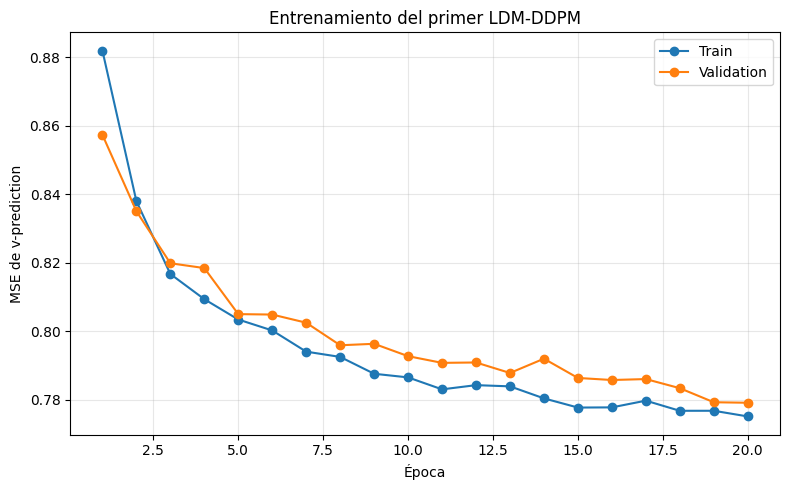

In [60]:
epochs = np.arange(1, len(ldm_history_first["train"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, ldm_history_first["train"], marker="o", label="Train")
plt.plot(epochs, ldm_history_first["val"], marker="o", label="Validation")

plt.xlabel("Época")
plt.ylabel("MSE de v-prediction")
plt.title("Entrenamiento del primer LDM-DDPM")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
@torch.no_grad()
def latent_ddpm_reverse_step_v(model, scheduler, z_t, timestep):
    
    batch_size = z_t.shape[0]
    t_batch = torch.full((batch_size,), timestep, device=z_t.device, dtype=torch.long)
    v_prediction = model(z_t, t_batch)
    sqrt_alpha_bar_t = scheduler.sqrt_alpha_cum_prod[timestep]
    sqrt_one_minus_alpha_bar_t = scheduler.sqrt_one_minus_alpha_cum_prod[timestep]
    z0_prediction = sqrt_alpha_bar_t * z_t - sqrt_one_minus_alpha_bar_t * v_prediction

    if timestep == 0:
        return z0_prediction, z0_prediction

    posterior_mean = scheduler.posterior_mean_coef1[timestep] * z0_prediction + scheduler.posterior_mean_coef2[timestep] * z_t
    posterior_variance = scheduler.posterior_variance[timestep].clamp_min(1e-20)
    noise = torch.randn_like(z_t)
    z_previous = posterior_mean + torch.sqrt(posterior_variance) * noise

    return z_previous, z0_prediction

In [71]:
@torch.no_grad()
def generate_standardized_latents_ddpm(model, scheduler, num_samples, latent_shape=(4, 16, 16), device=device, seed=42):
    """Genera latentes estandarizados mediante los 1000 pasos inversos del DDPM."""
    model.eval()
    if seed is not None:
        torch.manual_seed(seed)

    z_t = torch.randn((num_samples, *latent_shape), device=device)

    for timestep in reversed(range(scheduler.num_timesteps)):
        z_t, _ = latent_ddpm_reverse_step_v(model=model, scheduler=scheduler, z_t=z_t, timestep=timestep)
        
        if timestep % 100 == 0 and not torch.isfinite(z_t).all():
            raise RuntimeError(f"Aparecieron NaN o infinitos durante el timestep {timestep}.")

    if not torch.isfinite(z_t).all():
        raise RuntimeError("Los latentes finales contienen NaN o infinitos.")

    return z_t

In [72]:
NUM_GENERATED_SAMPLES = 16

generated_latents_standardized = generate_standardized_latents_ddpm(model=ldm_model_first, scheduler=ldm_scheduler, num_samples=NUM_GENERATED_SAMPLES, latent_shape=(4, 16, 16), device=device, seed=SEED)

print("Shape:", generated_latents_standardized.shape)
print("Valores finitos:", torch.isfinite(generated_latents_standardized).all().item())

Shape: torch.Size([16, 4, 16, 16])
Valores finitos: True


In [64]:
@torch.no_grad()
def decode_generated_latents(vae_model, latent_tensor, probability_threshold=0.8):
    vae_model.eval()

    generated_images_m11 = vae_model.decode_hard(latent_tensor, probability_threshold=probability_threshold)
    generated_images_01 = ((generated_images_m11 + 1.0) / 2.0).clamp(0.0, 1.0)

    return generated_images_01

In [67]:
latent_mean_device = (
    latent_mean_train
    .to(device)
    .float()
)

latent_std_device = (
    latent_std_train
    .to(device)
    .float()
)

generated_latents_original = (
    generated_latents_standardized
    * latent_std_device
    + latent_mean_device
)

In [68]:
generated_jets_01 = decode_generated_latents(vae_model=vae_model, latent_tensor=generated_latents_original, probability_threshold=0.8)

print("Jets generados:", generated_jets_01.shape)
print("Mínimo:", generated_jets_01.min().item())
print("Máximo:", generated_jets_01.max().item())
print("Valores finitos:", torch.isfinite(generated_jets_01).all().item())

Jets generados: torch.Size([16, 3, 64, 64])
Mínimo: 0.0
Máximo: 0.9941678047180176
Valores finitos: True


In [69]:
def plot_generated_jets(generated_images_01, num_images=8, contrast=True):
    images = generated_images_01.detach().float().cpu()
    num_images = min(num_images, images.shape[0])
    
    num_columns = 4
    num_rows = int(np.ceil(num_images / num_columns))
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(3.4 * num_columns, 3.4 * num_rows))
    axes = np.asarray(axes).reshape(-1)

    for index in range(num_images):
        image = images[index]
        total_intensity = image.sum().item()
        maximum = image.max().item()
        active_fraction = (image > 1e-4).float().mean().item()
        image_to_show = image.permute(1, 2, 0).numpy()

        if contrast:
            display_maximum = image_to_show.max()
            if display_maximum > 0:
                image_to_show = image_to_show / display_maximum

        axes[index].imshow(image_to_show)
        axes[index].set_title(f"Jet {index + 1}\nI={total_intensity:.2f}, max={maximum:.3f}\nact={100*active_fraction:.2f}%")
        axes[index].axis("off")

    for index in range(num_images, len(axes)):
        axes[index].axis("off")

    fig.tight_layout()
    plt.show()

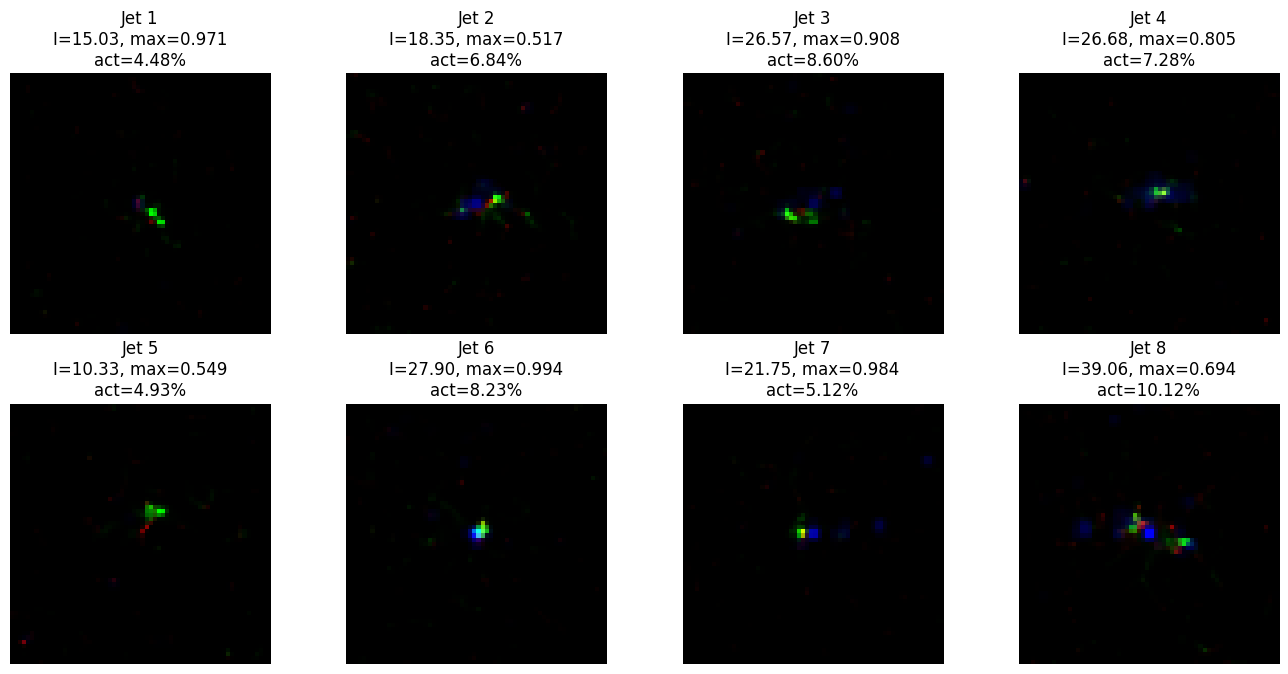

In [70]:
plot_generated_jets(
    generated_jets_01,
    num_images=8,
    contrast=True,
)